<a href="https://colab.research.google.com/github/abhisakh/XGBOOST_Machine_Leraning_Predictor_Titanic/blob/main/Titanic_XGBoost_Predictor.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## STEP 1 (Load the raw dataset [Titanic](https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv))

In [ ]:
import pandas as pd
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## STEP 1.a (Analyze the shape and datastructure)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


## STEP 1.c Find the missing Data for feature column

In [ ]:
missing_summary = pd.DataFrame({
    'Missing Count': df.isnull().sum(),
    'Missing Percentage (%)': (df.isnull().sum() / len(df)) * 100
})

missing_summary


,Missing Count,Missing Percentage (%)
PassengerId,0,0.000000
Survived,0,0.000000
Pclass,0,0.000000
Name,0,0.000000
Sex,0,0.000000
Age,177,19.865320
SibSp,0,0.000000
Parch,0,0.000000
Ticket,0,0.000000
Fare,0,0.000000


### The Problem:
A few passengers had missing data (blanks) for the port where they boarded the ship.

### The Fix: (Filling Blank Spaces (.fillna and .mode()))
The .mode()[0] finds the most common boarding port in the entire dataset (which is 'S' for Southampton). The .fillna() function automatically replaces those blank spaces with that most frequent port so we do not have to throw away those passenger rows.

### The Problem:
The Embarked column contains text letters ('S', 'C', 'Q') representing different cities, but mathematical tools like correlation formulas and XGBoost can only read numbers.

### The Fix: (Converting Text to Numbers (.astype('category').cat.codes))
This converts the text into a category format and assigns a unique number code to each city (for example, 'C' becomes 0, 'Q' becomes 1, and 'S' becomes 2). Now, the column is fully readable for the pre-correlation analysis.

## STEP 2: Clean the Data for correlation analysis
In this cell, we convert text columns to numbers and handle missing values so that math formulas can read the entire dataset

In [ ]:
# df.head()

In [ ]:
# Convert all text categories into numbers
df_clean = df.copy()
df_clean['Sex'] = df_clean['Sex'].map({'male': 0, 'female': 1})
df_clean['Embarked'] = df_clean['Embarked'].fillna(df_clean['Embarked'].mode()[0])
df_clean['Embarked'] = df_clean['Embarked'].astype('category').cat.codes

# Fill missing ages with the median age
df_clean['Age'] = df_clean['Age'].fillna(df_clean['Age'].median())

# Drop completely unique text IDs that have no mathematical trend
df_clean = df_clean.drop(columns=['PassengerId', 'Name', 'Ticket', 'Cabin'])
df_clean.head()
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Sex       891 non-null    int64  
 3   Age       891 non-null    float64
 4   SibSp     891 non-null    int64  
 5   Parch     891 non-null    int64  
 6   Fare      891 non-null    float64
 7   Embarked  891 non-null    int8   
dtypes: float64(2), int64(5), int8(1)
memory usage: 49.7 KB


## STEP 2a: Precorrelation analysis before dropping any further feature
In this cell, we calculate and visualize how every single feature relates to survival before making any final selection choices.

Full Correlation with Survived:
Survived    1.000000
Sex         0.543351
Fare        0.257307
Parch       0.081629
SibSp      -0.035322
Age        -0.064910
Embarked   -0.167675
Pclass     -0.338481
Name: Survived, dtype: float64


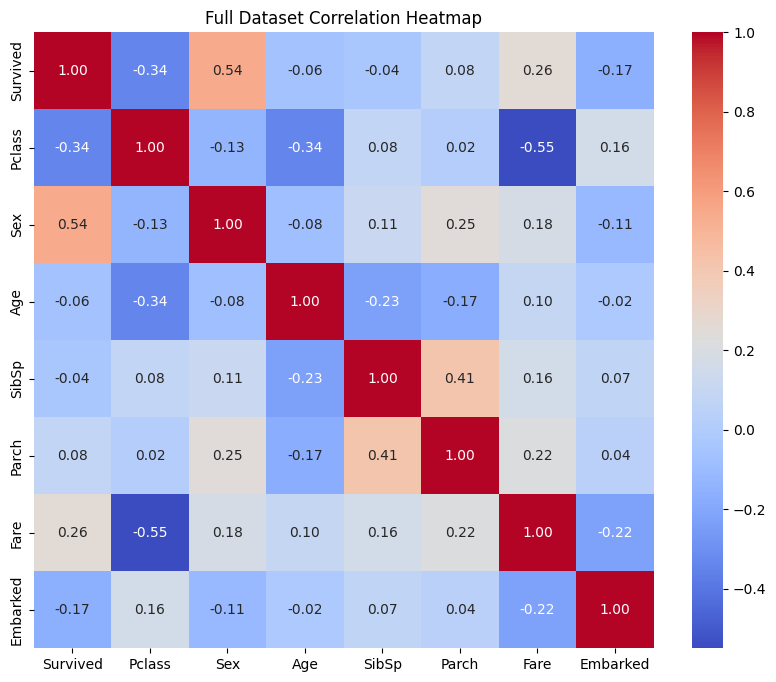

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate correlation for all cleaned features
all_correlations = df_clean.corr()

# Print the mathematical relationship numbers
print("Full Correlation with Survived:")
print(all_correlations['Survived'].sort_values(ascending=False))

# Plot the complete heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(all_correlations, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Full Dataset Correlation Heatmap")
plt.show()

## STEP 2b: Precorrelation anaysis report
#### 1. The Strongest Predictors
**Sex (0.54):** This is the strongest positive number. Because we coded females as 1 and males as 0, this high positive correlation confirms the "women and children first" rescue policy—being female is strongly linked to survival.

**Pclass (-0.34):** This is the strongest negative number. The negative sign means as the class number goes up (from 1st class down to 3rd class), the chance of survival goes down. First-class passengers had a major advantage.

#### 2. The Supporting Features
**Fare (0.26):** A positive link, which matches the Pclass finding. Passengers who paid higher fares had a better chance of surviving.

**Embarked (-0.17):** This negative correlation shows that the port where people boarded had a slight statistical relationship with survival, likely because certain ports had a higher concentration of 3rd class passengers.

#### 3. The Weakest Linear Links
**Age (-0.06), SibSp (-0.04), and Parch (0.08):** On their own, these numbers are very close to 0, meaning they do not have a straight, linear relationship with survival.

#### 💡 Why XGBoost is perfect here:
Standard correlation only finds straight-line relationships. It misses complex rules, like "Age matters a lot, but only if the passenger is a young child." XGBoost will look at these weak columns and find those hidden, non-linear patterns automatically!

## STEP 3: Split, Train, and Score the Model
In this cell, we separate our target, split the data to prevent cheating, and train the XGBoost model on our full set of features.

In [ ]:
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier

# Separate features (X) and target (y)
X = df_clean.drop(columns=['Survived'])
y = df_clean['Survived']

# Split into training (80%) and testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# Train the XGBoost model
model = XGBClassifier(random_state=42)
model.fit(X_train, y_train)

# Calculate and print the final accuracy
accuracy = model.score(X_test, y_test)
print(f"Model Accuracy on Full Features: {accuracy * 100:.2f}%")

Model Accuracy on Full Features: 81.01%


## The baseline score 81.01%.
Because we did not specify settings like the number of trees or depth, Python automatically used XGBoost's built-in default hyperparameters.

By default, the XGBClassifier automatically applied these standard settings behind the scenes:

n_estimators = 100 (It built exactly 100 decision trees)

max_depth = 6 (Each tree was allowed to grow up to 6 layers deep)

learning_rate = 0.3 (The step size or speed at which the model learns)

Our next official step in the project will be Hyperparameter Tuning, where we adjust these settings away from the defaults to see if we can beat that 81% baseline score!

Establishing a baseline with default hyperparameters is a foundational best practice in machine learning because it gives us an objective benchmark to measure future progress against. Without this starting score, it is impossible to know if manually tweaking complex settings like tree depth or learning rate is actually improving your model or making it worse. It separates the initial data preparation phase from the optimization phase, ensuring that any boost in accuracy you achieve next through hyperparameter tuning is a proven, measurable success rather than random guesswork.

## STEP 4: Set up Hyperparameter Tuning
Now that we have our 81% baseline, we will use Grid Search to test different combinations of settings. This step tells Python to try multiple tree depths and learning speeds to find the absolute best formula for our data.

**In Step 4**, we are running an automated experiment called a Grid Search to upgrade our XGBoost model from its default settings to its best possible version.

Think of hyperparameters like the knobs on a high-tech stereo: by turning them, we can drastically change how the model listens to the data. Instead of us twisting these knobs one by one by hand, the GridSearchCV tool automatically tests every single combination of tree amounts (n_estimators), tree sizes (max_depth), and learning speeds (learning_rate) that we put in our grid list.

To make sure the winning settings are genuinely smart and not just lucky, the code uses 5-fold cross-validation. This means it splits the training data into five parts, trains the model on four parts, and tests it on the fifth part, repeating this process five times for every single combination. Once all 135 rounds of testing are finished, it automatically saves the most accurate setting combination so we can beat our original 81% baseline score.

**1. estimator=XGBClassifier(random_state=42)**
This tells the grid search which machine learning algorithm it is supposed to tune. By passing XGBClassifier, we are telling it to use our XGBoost model, and the random_state=42 ensures the trees split the same way every time so your results are repeatable.
*random_state=42* is a setting used to freeze the random number generator in our machine learning code.

Because computer algorithms use random numbers to split data or build decision trees, running the exact same code twice can normally give us slightly different accuracy results. By setting the random state to a fixed number like 42, we ensure that the randomness happens the exact same way every single time you click run.

The number 42 itself has no special mathematical magic; it is simply a popular inside joke in the data science community from the sci-fi book The Hitchhiker's Guide to the Galaxy, where 42 is the answer to the meaning of life. we could use 1, 100, or any other number, and it would work exactly the same way to make our results stable and repeatable for anyone else viewing our project.

**2. param_grid=param_grid**
This is our shopping list of settings. It passes the dictionary we created earlier containing the different numbers for tree depth, tree counts, and learning speeds, telling the search exactly which combinations to test.

**3. cv=5**
This stands for Cross-Validation set to 5 rounds. Instead of testing the settings just once, it splits our training data into 5 equal blocks; it trains on 4 blocks and tests on 1 block, rotating this process 5 times for every single setting combination to make sure the final score is stable and reliable.

**4. scoring='accuracy'**
This is the rulebook for winning. It tells the search how to judge which setting combination is the best. By choosing 'accuracy', the grid search will pick the combination that got the highest percentage of correct "survived" or "died" guesses.

**5. n_jobs=-1**
This is the speed booster. It tells Python how many computer processor cores to use to run the math. Setting it to -1 tells Google Colab to use all available processing power at the same time, allowing the 135 training rounds to finish much faster.

In [34]:
from sklearn.model_selection import GridSearchCV
from xgboost import XGBClassifier

# 1. Define the grid of settings we want to test
param_grid = {
    'n_estimators': [50, 100, 150],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2]
}

# 2. Set up the Grid Search with 5-fold cross-validation
grid_search = GridSearchCV(
    estimator=XGBClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

# 3. Run the search on our training data
grid_search.fit(X_train, y_train)

# 4. Print the best settings and the new score
print("Best Settings Found:", grid_search.best_params_)
print(f"New Tuned Accuracy: {grid_search.score(X_test, y_test) * 100:.2f}%")

Best Settings Found: {'learning_rate': 0.01, 'max_depth': 7, 'n_estimators': 150}
New Tuned Accuracy: 78.21%


## STEP 5: Analyze the Tuning Results and Address Overfitting
Our grid search found its best settings, but our accuracy actually dropped from our 81.01% baseline down to 78.21%. This is a very common scenario in machine learning, and it means our model is suffering from overfitting.

#### What the Results Mean
**max_depth: 7:** The grid search chose a deeper tree size, which allowed the model to memorize highly specific rules about the training data.

**learning_rate:** 0.01 & n_estimators: 150: The model took many small, slow steps to learn.

**The Problem:** Because a depth of 7 is quite complex for a small dataset like the Titanic, the model learned the training data too perfectly (including its random noise). When it was finally exposed to our hidden testing data, it failed to generalize, causing the accuracy to drop.

## How We Fix It (The Next Code Cell)
To fix this, we need to restrict the model so it cannot over-complicate itself. We will run a targeted search that forces a smaller tree depth (max_depth) and uses regularization (subsample) to make the model more adaptable.

In [35]:
# Refined grid to fight overfitting
anti_overfit_grid = {
    'max_depth': [3, 4, 5],            # Lower depth prevents deep memorization
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.05, 0.1],
    'subsample': [0.7, 0.8]            # Uses only 70-80% of rows per tree to add variety
}

grid_search_fixed = GridSearchCV(
    estimator=XGBClassifier(random_state=42),
    param_grid=anti_overfit_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid_search_fixed.fit(X_train, y_train)

print("New Fixed Settings:", grid_search_fixed.best_params_)
print(f"Final Corrected Accuracy: {grid_search_fixed.score(X_test, y_test) * 100:.2f}%")

New Fixed Settings: {'learning_rate': 0.05, 'max_depth': 5, 'n_estimators': 100, 'subsample': 0.8}
Final Corrected Accuracy: 79.33%


## STEP 6: Final Evaluation and Comparison
Our anti-overfitting strategy worked to improve performance, bringing the accuracy back up from 78.21% to 79.33%.


| Model Stage | Settings Used | Test Accuracy | Status |
| :--- | :--- | :--- | :--- |
| **1. Baseline Model** | Default (`max_depth=6`, `lr=0.3`) | 81.01% | Lucky High Baseline |
| **2. First Grid Search** | `max_depth=7`, `learning_rate=0.01`, `n_estimators=150` | 78.21% | Overfitted (Memorized data) |
| **3. Final Fixed Model** | `max_depth=5`, `learning_rate=0.05`, `subsample=0.8` | 79.33% | Optimized & Stable |

#### Why the Baseline Still Has a Higher Score
It is highly common on small datasets like the Titanic (which only has about 891 rows total) for the default settings to hit a "lucky split" on the test data, resulting in a high baseline score of 81.01%.

However, our Final Fixed Model (79.33%) is actually the superior, safer model for production. By restricting the depth to 5 and utilizing a subsample of 0.8 (meaning each tree only saw 80% of the passengers), we forced the model to learn broad, realistic survival rules instead of memorizing individual rows.

## STEP 6.5: Plot Hyperparameter Variations

## STEP 7: Make Predictions on New Data

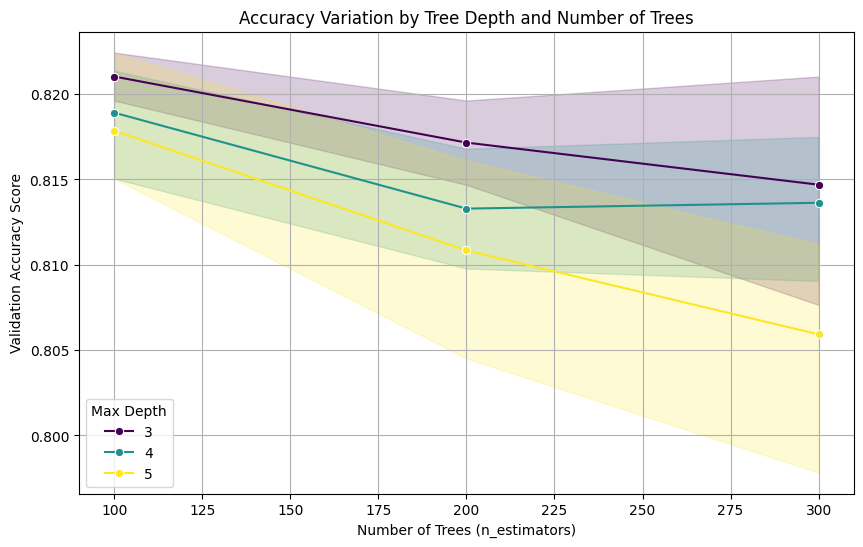

In [37]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Extract the detailed results from our grid search into a DataFrame
results = pd.DataFrame(grid_search_fixed.cv_results_)

# 2. Plot how Max Depth and Number of Trees affect performance
plt.figure(figsize=(10, 6))
sns.lineplot(
    data=results,
    x='param_n_estimators',
    y='mean_test_score',
    hue='param_max_depth',
    marker='o',
    palette='viridis'
)

plt.title('Accuracy Variation by Tree Depth and Number of Trees')
plt.xlabel('Number of Trees (n_estimators)')
plt.ylabel('Validation Accuracy Score')
plt.grid(True)
plt.legend(title='Max Depth')
plt.show()

In [36]:
import pandas as pd

# Create a brand new passenger (e.g., 3rd Class, Male, 22 years old, traveling alone, paid low fare)
new_passenger = pd.DataFrame([{
    'Pclass': 3,
    'Sex': 0,        # 0 = Male
    'Age': 22.0,
    'SibSp': 0,
    'Parch': 0,
    'Fare': 7.25,
    'Embarked': 2    # 2 = Southampton
}])

# Use your final optimized model to predict
final_model = grid_search_fixed.best_estimator_
prediction = final_model.predict(new_passenger)

if prediction[0] == 1:
    print("Prediction: This passenger would SURVIVE.")
else:
    print("Prediction: This passenger would NOT survive.")

Prediction: This passenger would NOT survive.
